# Lab 3: Audio Deepfake detection (Part B) - Deep Learning Methods

## Dataset (ASVspoof 2019_LA)

`ASVspoof2019` is the third edition of the Automatic Speaker Verification Spoofing and Countermeasures Challenge, which focuses on detecting spoofing attacks against **automatic speaker verification (ASV)** systems. It has two main tracks, and the `LA (Logical Access)` subset is one of them. The LA track includes **19** different spoofing attacks in the training/dev sets, spanning multiple categories:
- Text-to-Speech (TTS): completely synthetic speech
- Voice Conversion (VC): converting one speaker's voice to another's

These attacks use both `known` and `unknown` (or unseen) algorithms, testing the system's generalization ability. Below is the dataset structure:
- `Training set`: Genuine + 4 spoofing algorithms (2 TTS, 2 VC)
- `Development set`: Different speakers, same 4 attacks as training
- `Evaluation set`: Includes 13 additional unknown attack algorithms (7 TTS, 6 VC) not seen in training/dev, plus the known ones — this is what makes the challenge hard

Labels:
- `spoof`: spoofed audio
- `bonafide`: genuine (real) speech

You can download the dataset via the link: https://datashare.ed.ac.uk/handle/10283/3336

## ASSIST

`AASIST` stands for ***Audio Anti-Spoofing System Integrated with Spectro-Temporal Graph Attention Networks***. It is a state-of-the-art deep learning model specifically designed for detecting spoofed (fake) audio, including deepfakes produced by text-to-speech (TTS), voice conversion (VC), or replay attacks. In this part, we will load the pre-trained weight of AASIST baed on the official implementation (https://github.com/clovaai/aasist)

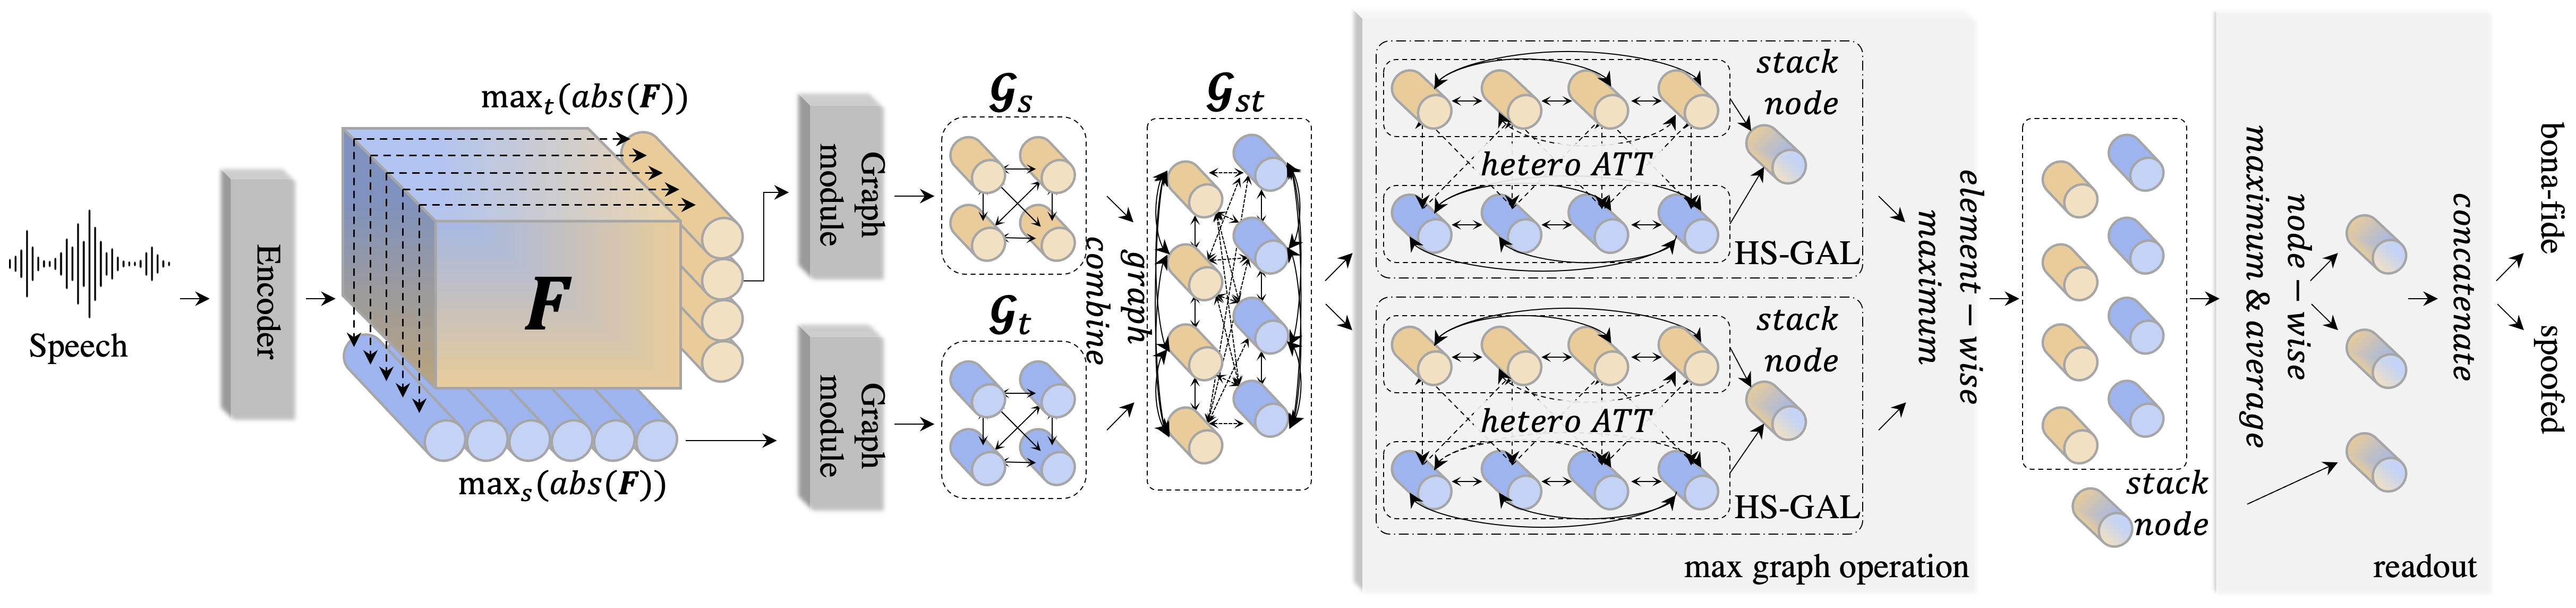

You can read the paper from the link: https://arxiv.org/pdf/2110.01200

In [63]:
import torch

Define the AASIST architecture (The source code can be found in https://github.com/clovaai/aasist/blob/main/models/AASIST.py)

In [64]:
"""
AASIST
Copyright (c) 2021-present NAVER Corp.
MIT license
"""

import random
from typing import Union

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import Tensor


class GraphAttentionLayer(nn.Module):
  def __init__(self, in_dim, out_dim, **kwargs):
    super().__init__()

    # attention map
    self.att_proj = nn.Linear(in_dim, out_dim)
    self.att_weight = self._init_new_params(out_dim, 1)

    # project
    self.proj_with_att = nn.Linear(in_dim, out_dim)
    self.proj_without_att = nn.Linear(in_dim, out_dim)

    # batch norm
    self.bn = nn.BatchNorm1d(out_dim)

    # dropout for inputs
    self.input_drop = nn.Dropout(p=0.2)

    # activate
    self.act = nn.SELU(inplace=True)

    # temperature
    self.temp = 1.
    if "temperature" in kwargs:
        self.temp = kwargs["temperature"]

  def forward(self, x):
    '''
    x   :(#bs, #node, #dim)
    '''
    # apply input dropout
    x = self.input_drop(x)

    # derive attention map
    att_map = self._derive_att_map(x)

    # projection
    x = self._project(x, att_map)

    # apply batch norm
    x = self._apply_BN(x)
    x = self.act(x)
    return x

  def _pairwise_mul_nodes(self, x):
    '''
    Calculates pairwise multiplication of nodes.
    - for attention map
    x           :(#bs, #node, #dim)
    out_shape   :(#bs, #node, #node, #dim)
    '''

    nb_nodes = x.size(1)
    x = x.unsqueeze(2).expand(-1, -1, nb_nodes, -1)
    x_mirror = x.transpose(1, 2)

    return x * x_mirror

  def _derive_att_map(self, x):
    '''
    x           :(#bs, #node, #dim)
    out_shape   :(#bs, #node, #node, 1)
    '''
    att_map = self._pairwise_mul_nodes(x)
    # size: (#bs, #node, #node, #dim_out)
    att_map = torch.tanh(self.att_proj(att_map))
    # size: (#bs, #node, #node, 1)
    att_map = torch.matmul(att_map, self.att_weight)

    # apply temperature
    att_map = att_map / self.temp

    att_map = F.softmax(att_map, dim=-2)

    return att_map

  def _project(self, x, att_map):
    x1 = self.proj_with_att(torch.matmul(att_map.squeeze(-1), x))
    x2 = self.proj_without_att(x)

    return x1 + x2

  def _apply_BN(self, x):
    org_size = x.size()
    x = x.view(-1, org_size[-1])
    x = self.bn(x)
    x = x.view(org_size)

    return x

  def _init_new_params(self, *size):
    out = nn.Parameter(torch.FloatTensor(*size))
    nn.init.xavier_normal_(out)
    return out


class HtrgGraphAttentionLayer(nn.Module):
  def __init__(self, in_dim, out_dim, **kwargs):
    super().__init__()

    self.proj_type1 = nn.Linear(in_dim, in_dim)
    self.proj_type2 = nn.Linear(in_dim, in_dim)

    # attention map
    self.att_proj = nn.Linear(in_dim, out_dim)
    self.att_projM = nn.Linear(in_dim, out_dim)

    self.att_weight11 = self._init_new_params(out_dim, 1)
    self.att_weight22 = self._init_new_params(out_dim, 1)
    self.att_weight12 = self._init_new_params(out_dim, 1)
    self.att_weightM = self._init_new_params(out_dim, 1)

    # project
    self.proj_with_att = nn.Linear(in_dim, out_dim)
    self.proj_without_att = nn.Linear(in_dim, out_dim)

    self.proj_with_attM = nn.Linear(in_dim, out_dim)
    self.proj_without_attM = nn.Linear(in_dim, out_dim)

    # batch norm
    self.bn = nn.BatchNorm1d(out_dim)

    # dropout for inputs
    self.input_drop = nn.Dropout(p=0.2)

    # activate
    self.act = nn.SELU(inplace=True)

    # temperature
    self.temp = 1.
    if "temperature" in kwargs:
        self.temp = kwargs["temperature"]

  def forward(self, x1, x2, master=None):
    '''
    x1  :(#bs, #node, #dim)
    x2  :(#bs, #node, #dim)
    '''
    num_type1 = x1.size(1)
    num_type2 = x2.size(1)

    x1 = self.proj_type1(x1)
    x2 = self.proj_type2(x2)

    x = torch.cat([x1, x2], dim=1)

    if master is None:
        master = torch.mean(x, dim=1, keepdim=True)

    # apply input dropout
    x = self.input_drop(x)

    # derive attention map
    att_map = self._derive_att_map(x, num_type1, num_type2)

    # directional edge for master node
    master = self._update_master(x, master)

    # projection
    x = self._project(x, att_map)

    # apply batch norm
    x = self._apply_BN(x)
    x = self.act(x)

    x1 = x.narrow(1, 0, num_type1)
    x2 = x.narrow(1, num_type1, num_type2)

    return x1, x2, master

  def _update_master(self, x, master):
    att_map = self._derive_att_map_master(x, master)
    master = self._project_master(x, master, att_map)

    return master

  def _pairwise_mul_nodes(self, x):
    '''
    Calculates pairwise multiplication of nodes.
    - for attention map
    x           :(#bs, #node, #dim)
    out_shape   :(#bs, #node, #node, #dim)
    '''

    nb_nodes = x.size(1)
    x = x.unsqueeze(2).expand(-1, -1, nb_nodes, -1)
    x_mirror = x.transpose(1, 2)

    return x * x_mirror

  def _derive_att_map_master(self, x, master):
    '''
    x           :(#bs, #node, #dim)
    out_shape   :(#bs, #node, #node, 1)
    '''
    att_map = x * master
    att_map = torch.tanh(self.att_projM(att_map))

    att_map = torch.matmul(att_map, self.att_weightM)

    # apply temperature
    att_map = att_map / self.temp

    att_map = F.softmax(att_map, dim=-2)

    return att_map

  def _derive_att_map(self, x, num_type1, num_type2):
    '''
    x           :(#bs, #node, #dim)
    out_shape   :(#bs, #node, #node, 1)
    '''
    att_map = self._pairwise_mul_nodes(x)
    # size: (#bs, #node, #node, #dim_out)
    att_map = torch.tanh(self.att_proj(att_map))
    # size: (#bs, #node, #node, 1)

    att_board = torch.zeros_like(att_map[:, :, :, 0]).unsqueeze(-1)

    att_board[:, :num_type1, :num_type1, :] = torch.matmul(
        att_map[:, :num_type1, :num_type1, :], self.att_weight11)
    att_board[:, num_type1:, num_type1:, :] = torch.matmul(
        att_map[:, num_type1:, num_type1:, :], self.att_weight22)
    att_board[:, :num_type1, num_type1:, :] = torch.matmul(
        att_map[:, :num_type1, num_type1:, :], self.att_weight12)
    att_board[:, num_type1:, :num_type1, :] = torch.matmul(
        att_map[:, num_type1:, :num_type1, :], self.att_weight12)

    att_map = att_board

    # att_map = torch.matmul(att_map, self.att_weight12)

    # apply temperature
    att_map = att_map / self.temp

    att_map = F.softmax(att_map, dim=-2)

    return att_map

  def _project(self, x, att_map):
    x1 = self.proj_with_att(torch.matmul(att_map.squeeze(-1), x))
    x2 = self.proj_without_att(x)

    return x1 + x2

  def _project_master(self, x, master, att_map):
    x1 = self.proj_with_attM(torch.matmul(
        att_map.squeeze(-1).unsqueeze(1), x))
    x2 = self.proj_without_attM(master)

    return x1 + x2

  def _apply_BN(self, x):
    org_size = x.size()
    x = x.view(-1, org_size[-1])
    x = self.bn(x)
    x = x.view(org_size)

    return x

  def _init_new_params(self, *size):
    out = nn.Parameter(torch.FloatTensor(*size))
    nn.init.xavier_normal_(out)
    return out


class GraphPool(nn.Module):
  def __init__(self, k: float, in_dim: int, p: Union[float, int]):
    super().__init__()
    self.k = k
    self.sigmoid = nn.Sigmoid()
    self.proj = nn.Linear(in_dim, 1)
    self.drop = nn.Dropout(p=p) if p > 0 else nn.Identity()
    self.in_dim = in_dim

  def forward(self, h):
    Z = self.drop(h)
    weights = self.proj(Z)
    scores = self.sigmoid(weights)
    new_h = self.top_k_graph(scores, h, self.k)

    return new_h

  def top_k_graph(self, scores, h, k):
    """
    args
    =====
    scores: attention-based weights (#bs, #node, 1)
    h: graph data (#bs, #node, #dim)
    k: ratio of remaining nodes, (float)

    returns
    =====
    h: graph pool applied data (#bs, #node', #dim)
    """
    _, n_nodes, n_feat = h.size()
    n_nodes = max(int(n_nodes * k), 1)
    _, idx = torch.topk(scores, n_nodes, dim=1)
    idx = idx.expand(-1, -1, n_feat)

    h = h * scores
    h = torch.gather(h, 1, idx)

    return h


class CONV(nn.Module):
  @staticmethod
  def to_mel(hz):
    return 2595 * np.log10(1 + hz / 700)

  @staticmethod
  def to_hz(mel):
    return 700 * (10**(mel / 2595) - 1)

  def __init__(self,
                out_channels,
                kernel_size,
                sample_rate=16000,
                in_channels=1,
                stride=1,
                padding=0,
                dilation=1,
                bias=False,
                groups=1,
                mask=False):
    super().__init__()
    if in_channels != 1:

        msg = "SincConv only support one input channel (here, in_channels = {%i})" % (
            in_channels)
        raise ValueError(msg)
    self.out_channels = out_channels
    self.kernel_size = kernel_size
    self.sample_rate = sample_rate

    # Forcing the filters to be odd (i.e, perfectly symmetrics)
    if kernel_size % 2 == 0:
      self.kernel_size = self.kernel_size + 1
    self.stride = stride
    self.padding = padding
    self.dilation = dilation
    self.mask = mask
    if bias:
      raise ValueError('SincConv does not support bias.')
    if groups > 1:
      raise ValueError('SincConv does not support groups.')

    NFFT = 512
    f = int(self.sample_rate / 2) * np.linspace(0, 1, int(NFFT / 2) + 1)
    fmel = self.to_mel(f)
    fmelmax = np.max(fmel)
    fmelmin = np.min(fmel)
    filbandwidthsmel = np.linspace(fmelmin, fmelmax, self.out_channels + 1)
    filbandwidthsf = self.to_hz(filbandwidthsmel)

    self.mel = filbandwidthsf
    self.hsupp = torch.arange(-(self.kernel_size - 1) / 2,
                              (self.kernel_size - 1) / 2 + 1)
    self.band_pass = torch.zeros(self.out_channels, self.kernel_size)
    for i in range(len(self.mel) - 1):
      fmin = self.mel[i]
      fmax = self.mel[i + 1]
      hHigh = (2*fmax/self.sample_rate) * \
          np.sinc(2*fmax*self.hsupp/self.sample_rate)
      hLow = (2*fmin/self.sample_rate) * \
          np.sinc(2*fmin*self.hsupp/self.sample_rate)
      hideal = hHigh - hLow

      self.band_pass[i, :] = Tensor(np.hamming(self.kernel_size)) * Tensor(hideal)

  def forward(self, x, mask=False):
    band_pass_filter = self.band_pass.clone().to(x.device)
    if mask:
      A = np.random.uniform(0, 20)
      A = int(A)
      A0 = random.randint(0, band_pass_filter.shape[0] - A)
      band_pass_filter[A0:A0 + A, :] = 0
    else:
      band_pass_filter = band_pass_filter

    self.filters = (band_pass_filter).view(self.out_channels, 1, self.kernel_size)

    return F.conv1d(x,
                    self.filters,
                    stride=self.stride,
                    padding=self.padding,
                    dilation=self.dilation,
                    bias=None,
                    groups=1)


class Residual_block(nn.Module):
  def __init__(self, nb_filts, first=False):
    super().__init__()
    self.first = first

    if not self.first:
      self.bn1 = nn.BatchNorm2d(num_features=nb_filts[0])
    self.conv1 = nn.Conv2d(in_channels=nb_filts[0],
                            out_channels=nb_filts[1],
                            kernel_size=(2, 3),
                            padding=(1, 1),
                            stride=1)
    self.selu = nn.SELU(inplace=True)

    self.bn2 = nn.BatchNorm2d(num_features=nb_filts[1])
    self.conv2 = nn.Conv2d(in_channels=nb_filts[1],
                            out_channels=nb_filts[1],
                            kernel_size=(2, 3),
                            padding=(0, 1),
                            stride=1)

    if nb_filts[0] != nb_filts[1]:
      self.downsample = True
      self.conv_downsample = nn.Conv2d(in_channels=nb_filts[0],
                                        out_channels=nb_filts[1],
                                        padding=(0, 1),
                                        kernel_size=(1, 3),
                                        stride=1)
    else:
      self.downsample = False
    
    self.mp = nn.MaxPool2d((1, 3))  # self.mp = nn.MaxPool2d((1,4))

  def forward(self, x):
    identity = x
    if not self.first:
      out = self.bn1(x)
      out = self.selu(out)
    else:
      out = x
    out = self.conv1(x)

    # print('out',out.shape)
    out = self.bn2(out)
    out = self.selu(out)
    # print('out',out.shape)
    out = self.conv2(out)
    #print('conv2 out',out.shape)
    if self.downsample:
      identity = self.conv_downsample(identity)

    out += identity
    out = self.mp(out)
    return out


class Model(nn.Module):
  def __init__(self, d_args):
    super().__init__()

    self.d_args = d_args
    filts = d_args["filts"]
    gat_dims = d_args["gat_dims"]
    pool_ratios = d_args["pool_ratios"]
    temperatures = d_args["temperatures"]

    self.conv_time = CONV(out_channels=filts[0],
                          kernel_size=d_args["first_conv"],
                          in_channels=1)
    self.first_bn = nn.BatchNorm2d(num_features=1)

    self.drop = nn.Dropout(0.5, inplace=True)
    self.drop_way = nn.Dropout(0.2, inplace=True)
    self.selu = nn.SELU(inplace=True)

    self.encoder = nn.Sequential(
      nn.Sequential(Residual_block(nb_filts=filts[1], first=True)),
      nn.Sequential(Residual_block(nb_filts=filts[2])),
      nn.Sequential(Residual_block(nb_filts=filts[3])),
      nn.Sequential(Residual_block(nb_filts=filts[4])),
      nn.Sequential(Residual_block(nb_filts=filts[4])),
      nn.Sequential(Residual_block(nb_filts=filts[4]))
    )

    self.pos_S = nn.Parameter(torch.randn(1, 23, filts[-1][-1]))
    self.master1 = nn.Parameter(torch.randn(1, 1, gat_dims[0]))
    self.master2 = nn.Parameter(torch.randn(1, 1, gat_dims[0]))

    self.GAT_layer_S = GraphAttentionLayer(filts[-1][-1], gat_dims[0], temperature=temperatures[0])
    self.GAT_layer_T = GraphAttentionLayer(filts[-1][-1], gat_dims[0], temperature=temperatures[1])

    self.HtrgGAT_layer_ST11 = HtrgGraphAttentionLayer(
        gat_dims[0], gat_dims[1], temperature=temperatures[2])
    self.HtrgGAT_layer_ST12 = HtrgGraphAttentionLayer(
        gat_dims[1], gat_dims[1], temperature=temperatures[2])

    self.HtrgGAT_layer_ST21 = HtrgGraphAttentionLayer(
        gat_dims[0], gat_dims[1], temperature=temperatures[2])

    self.HtrgGAT_layer_ST22 = HtrgGraphAttentionLayer(
        gat_dims[1], gat_dims[1], temperature=temperatures[2])

    self.pool_S = GraphPool(pool_ratios[0], gat_dims[0], 0.3)
    self.pool_T = GraphPool(pool_ratios[1], gat_dims[0], 0.3)

    self.pool_hS1 = GraphPool(pool_ratios[2], gat_dims[1], 0.3)
    self.pool_hT1 = GraphPool(pool_ratios[2], gat_dims[1], 0.3)

    self.pool_hS2 = GraphPool(pool_ratios[2], gat_dims[1], 0.3)
    self.pool_hT2 = GraphPool(pool_ratios[2], gat_dims[1], 0.3)

    self.out_layer = nn.Linear(5 * gat_dims[1], 2)

  def forward(self, x, Freq_aug=False):
    x = x.unsqueeze(1)
    x = self.conv_time(x, mask=Freq_aug)
    x = x.unsqueeze(dim=1)
    x = F.max_pool2d(torch.abs(x), (3, 3))
    x = self.first_bn(x)
    x = self.selu(x)

    # get embeddings using encoder
    # (#bs, #filt, #spec, #seq)
    e = self.encoder(x)

    # spectral GAT (GAT-S)
    e_S, _ = torch.max(torch.abs(e), dim=3)  # max along time
    e_S = e_S.transpose(1, 2) + self.pos_S

    gat_S = self.GAT_layer_S(e_S)
    out_S = self.pool_S(gat_S)  # (#bs, #node, #dim)

    # temporal GAT (GAT-T)
    e_T, _ = torch.max(torch.abs(e), dim=2)  # max along freq
    e_T = e_T.transpose(1, 2)

    gat_T = self.GAT_layer_T(e_T)
    out_T = self.pool_T(gat_T)

    # learnable master node
    master1 = self.master1.expand(x.size(0), -1, -1)
    master2 = self.master2.expand(x.size(0), -1, -1)

    # inference 1
    out_T1, out_S1, master1 = self.HtrgGAT_layer_ST11(out_T, out_S, master=self.master1)

    out_S1 = self.pool_hS1(out_S1)
    out_T1 = self.pool_hT1(out_T1)

    out_T_aug, out_S_aug, master_aug = self.HtrgGAT_layer_ST12(out_T1, out_S1, master=master1)
    out_T1 = out_T1 + out_T_aug
    out_S1 = out_S1 + out_S_aug
    master1 = master1 + master_aug

    # inference 2
    out_T2, out_S2, master2 = self.HtrgGAT_layer_ST21(out_T, out_S, master=self.master2)
    out_S2 = self.pool_hS2(out_S2)
    out_T2 = self.pool_hT2(out_T2)

    out_T_aug, out_S_aug, master_aug = self.HtrgGAT_layer_ST22(out_T2, out_S2, master=master2)
    out_T2 = out_T2 + out_T_aug
    out_S2 = out_S2 + out_S_aug
    master2 = master2 + master_aug

    out_T1 = self.drop_way(out_T1)
    out_T2 = self.drop_way(out_T2)
    out_S1 = self.drop_way(out_S1)
    out_S2 = self.drop_way(out_S2)
    master1 = self.drop_way(master1)
    master2 = self.drop_way(master2)

    out_T = torch.max(out_T1, out_T2)
    out_S = torch.max(out_S1, out_S2)
    master = torch.max(master1, master2)

    T_max, _ = torch.max(torch.abs(out_T), dim=1)
    T_avg = torch.mean(out_T, dim=1)

    S_max, _ = torch.max(torch.abs(out_S), dim=1)
    S_avg = torch.mean(out_S, dim=1)

    last_hidden = torch.cat([T_max, T_avg, S_max, S_avg, master.squeeze(1)], dim=1)

    last_hidden = self.drop(last_hidden)
    output = self.out_layer(last_hidden)

    return last_hidden, output

Create the model based on the given configs. There are two configs: `AASIST.conf` & `AASIST-L.conf`. The latter one is the lightweight version with lesser parameters to the first one, but it can still achieve a better performance

In [65]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Regular config
# https://github.com/clovaai/aasist/blob/main/config/AASIST.conf
aasist_config = {
  "nb_samp": 64600,  # number of samples
  "first_conv": 128,
  "filts": [70, [1, 32], [32, 32], [32, 64], [64, 64]],
  "gat_dims": [64, 32],
  "pool_ratios": [0.5, 0.7, 0.5, 0.5],
  "temperatures": [2.0, 2.0, 100.0, 100.0]
}

# Lightweight config
# https://github.com/clovaai/aasist/blob/main/config/AASIST-L.conf
aasist_l_confit = {
  "nb_samp": 64600,
  "first_conv": 128,
  "filts": [70, [1, 32], [32, 32], [32, 24], [24, 24]],
  "gat_dims": [24, 32],
  "pool_ratios": [0.4, 0.5, 0.7, 0.5],
  "temperatures": [2.0, 2.0, 100.0, 100.0]
}

aasist = Model(aasist_l_confit).to(device)

Download the pre-train weight named `AASIST.pth` or `AASIST-L.pth` from Moodle. Load the pre-trained weights to the aasist model we created above

In [66]:
# aasist.load_state_dict(torch.load("./Weights/AASIST.pth", weights_only=True))
aasist.load_state_dict(torch.load("./Weights/AASIST-L.pth", weights_only=True))

<All keys matched successfully>

Load a bona-fide audio and a spoof audio for testing

In [103]:
# import torchaudio
import IPython.display as ipd
import librosa

file_bonafide = "./Dataset/bonafide1.wav"
file_spoof = "./Dataset/tts1.mp3"

sr = 16000

bonafide, sr1 = librosa.load(file_bonafide,sr=sr)
spoof, sr2 = librosa.load(file_spoof, sr=sr)

if isinstance(bonafide, np.ndarray):
  bonafide = torch.from_numpy(bonafide).unsqueeze(0)

if isinstance(spoof, np.ndarray):
  spoof = torch.from_numpy(spoof).unsqueeze(0)

print("Bonafide:")
ipd.display(ipd.Audio(data=bonafide, rate=sr1))

print("Spoof:")
ipd.display(ipd.Audio(data=spoof, rate=sr2))

Bonafide:


Spoof:


Perform the classification. We take the bonafide audio as an example

In [88]:
with torch.no_grad():
  aasist.eval()
  res = aasist(spoof.to(device))
  print(res)

(tensor([[ 0.8218,  0.7638,  0.5507,  0.9261,  0.9848,  0.8952,  0.7296,  0.3518,
          1.2205,  1.0154,  1.2428,  0.7892,  0.4472,  0.8628,  0.8700,  0.2643,
          0.8646,  1.1115,  0.6873,  0.6129,  0.8742,  1.3589,  0.8327,  0.8118,
          0.4686,  0.5663,  0.7369,  0.4097,  0.7024,  0.7736,  0.6416,  0.1753,
         -0.1244, -0.4074,  0.3542,  0.6058,  0.8095,  0.5912,  0.5293, -0.1447,
          0.6883, -0.7560,  0.8651,  0.4742,  0.2852,  0.6602,  0.5729, -0.1142,
          0.4637,  0.9754, -0.1003, -0.0110, -0.1384,  0.7455,  0.6699,  0.6565,
          0.1923,  0.3569,  0.2491,  0.0097, -0.2062,  0.5898,  0.4721,  0.0967,
          0.3943,  0.8515,  1.3202,  0.2236,  1.2676,  0.5840,  0.9763,  0.3890,
          0.3400,  0.7726,  0.2131,  0.4983,  0.2521,  1.2078,  0.7307,  1.1241,
          0.5639,  0.3191,  0.4463,  0.5855,  0.9080,  0.5338,  0.1942,  0.7926,
          0.5560,  0.7248,  0.8344,  0.6760,  0.7493,  0.7200,  0.5751,  0.7916,
          0.3242,  0.7014, 

The model returns a tuple that includes `last_hidden` and `classification scores`
- `last_hieedn`: This is the final learned feature representation (embedding) of the input audio, just before the final classification layer
- `output`: This is the classification result. It contains two **logits** (scores), corresponding to the class `spoof` and `bonafide`

Based on the source code, the model's output was pre-trained in the order of [`spoof`, `bonafide`]

In [89]:
classes = ['spoof', 'bonafide']

last_hidden = res[0]
output = res[1]
prediction = torch.argmax(output, dim=1).item()

print(f"The input audio is {classes[prediction]}")

The input audio is spoof


## RawNet2

`RawNet2` is another deep learning model designed for speaker verification directly from raw audio waveforms. It contains some key components like <u>Sinc-Convolution layer</u>, <u>Residual Convolutional Blocks</u>, and <u>Gated Recurrent Unit (GRU)</u>. In this part, we will also load the pre-trained weight of RawNet2 to implement the detection of spoofed audio

You can read the paper from the link: https://arxiv.org/abs/2011.01108

<img src="./Images/RawNet2.png" width=600 />

Define the architecture of RawNet2 (You can find the source code from https://github.com/clovaai/aasist/blob/main/models/RawNet2Spoof.py)

In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import Tensor
import numpy as np

class SincConv(nn.Module):
  @staticmethod
  def to_mel(hz):
    return 2595 * np.log10(1 + hz / 700)

  @staticmethod
  def to_hz(mel):
    return 700 * (10**(mel / 2595) - 1)

  def __init__(
    self,
    #device,
    out_channels,
    kernel_size,
    in_channels=1,
    sample_rate=16000,
    stride=1,
    padding=0,
    dilation=1,
    bias=False,
    groups=1,
  ):
    super().__init__()

    if in_channels != 1:
      msg = ("SincConv only support one input channel (here, in_channels = {%i})"% (in_channels))
      raise ValueError(msg)

    self.out_channels = out_channels
    self.kernel_size = kernel_size
    self.sample_rate = sample_rate

    # Forcing the filters to be odd (i.e, perfectly symmetrics)
    if kernel_size % 2 == 0:
      self.kernel_size = self.kernel_size + 1

    #self.device = device
    self.stride = stride
    self.padding = padding
    self.dilation = dilation

    if bias:
      raise ValueError("SincConv does not support bias.")
    if groups > 1:
      raise ValueError("SincConv does not support groups.")

    # initialize filterbanks using Mel scale
    NFFT = 512
    f = int(self.sample_rate / 2) * np.linspace(0, 1, int(NFFT / 2) + 1)
    fmel = self.to_mel(f)  # Hz to mel conversion
    fmelmax = np.max(fmel)
    fmelmin = np.min(fmel)
    filbandwidthsmel = np.linspace(fmelmin, fmelmax, self.out_channels + 1)
    filbandwidthsf = self.to_hz(filbandwidthsmel)  # Mel to Hz conversion
    self.mel = filbandwidthsf
    self.hsupp = torch.arange(-(self.kernel_size - 1) / 2, (self.kernel_size - 1) / 2 + 1)
    self.band_pass = torch.zeros(self.out_channels, self.kernel_size)

  def forward(self, x):
    for i in range(len(self.mel) - 1):
      fmin = self.mel[i]
      fmax = self.mel[i + 1]
      hHigh = (2 * fmax / self.sample_rate) * np.sinc(2 * fmax * self.hsupp / self.sample_rate)
      hLow = (2 * fmin / self.sample_rate) * np.sinc(2 * fmin * self.hsupp / self.sample_rate)
      hideal = hHigh - hLow

      self.band_pass[i, :] = Tensor(np.hamming(self.kernel_size)) * Tensor(hideal)

    band_pass_filter = self.band_pass.to(x.device)

    self.filters = (band_pass_filter).view(self.out_channels, 1, self.kernel_size)

    return F.conv1d(
      x,
      self.filters,
      stride=self.stride,
      padding=self.padding,
      dilation=self.dilation,
      bias=None,
      groups=1
    )


class Residual_block(nn.Module):
  def __init__(self, nb_filts, first=False):
    super(Residual_block, self).__init__()
    self.first = first

    if not self.first:
      self.bn1 = nn.BatchNorm1d(num_features=nb_filts[0])

    self.lrelu = nn.LeakyReLU(negative_slope=0.3)

    self.conv1 = nn.Conv1d(
      in_channels=nb_filts[0],
      out_channels=nb_filts[1],
      kernel_size=3,
      padding=1,
      stride=1
    )

    self.bn2 = nn.BatchNorm1d(num_features=nb_filts[1])
    self.conv2 = nn.Conv1d(
      in_channels=nb_filts[1],
      out_channels=nb_filts[1],
      padding=1,
      kernel_size=3,
      stride=1
    )

    if nb_filts[0] != nb_filts[1]:
      self.downsample = True
      self.conv_downsample = nn.Conv1d(
          in_channels=nb_filts[0],
          out_channels=nb_filts[1],
          padding=0,
          kernel_size=1,
          stride=1,
      )

    else:
      self.downsample = False

    self.mp = nn.MaxPool1d(3)

  def forward(self, x):
    identity = x
    if not self.first:
      out = self.bn1(x)
      out = self.lrelu(out)
    else:
      out = x

    out = self.conv1(x)
    out = self.bn2(out)
    out = self.lrelu(out)
    out = self.conv2(out)

    if self.downsample:
      identity = self.conv_downsample(identity)

    out += identity
    out = self.mp(out)
    return out


class Model(nn.Module):
  def __init__(self, d_args):
    super().__init__()

    #self.device = device
    self.Sinc_conv = SincConv(
      #device=self.device,
      out_channels=d_args["filts"][0],
      kernel_size=d_args["first_conv"],
      in_channels=d_args["in_channels"],
    )

    self.first_bn = nn.BatchNorm1d(num_features=d_args["filts"][0])
    self.selu = nn.SELU(inplace=True)
    self.block0 = nn.Sequential(Residual_block(nb_filts=d_args["filts"][1], first=True))
    self.block1 = nn.Sequential(Residual_block(nb_filts=d_args["filts"][1]))
    self.block2 = nn.Sequential(Residual_block(nb_filts=d_args["filts"][2]))
    d_args["filts"][2][0] = d_args["filts"][2][1]
    self.block3 = nn.Sequential(Residual_block(nb_filts=d_args["filts"][2]))
    self.block4 = nn.Sequential(Residual_block(nb_filts=d_args["filts"][2]))
    self.block5 = nn.Sequential(Residual_block(nb_filts=d_args["filts"][2]))
    self.avgpool = nn.AdaptiveAvgPool1d(1)

    self.fc_attention0 = self._make_attention_fc(in_features=d_args["filts"][1][-1], l_out_features=d_args["filts"][1][-1])
    self.fc_attention1 = self._make_attention_fc(in_features=d_args["filts"][1][-1], l_out_features=d_args["filts"][1][-1])
    self.fc_attention2 = self._make_attention_fc(in_features=d_args["filts"][2][-1], l_out_features=d_args["filts"][2][-1])
    self.fc_attention3 = self._make_attention_fc(in_features=d_args["filts"][2][-1], l_out_features=d_args["filts"][2][-1])
    self.fc_attention4 = self._make_attention_fc(in_features=d_args["filts"][2][-1], l_out_features=d_args["filts"][2][-1])
    self.fc_attention5 = self._make_attention_fc(in_features=d_args["filts"][2][-1], l_out_features=d_args["filts"][2][-1])

    self.bn_before_gru = nn.BatchNorm1d(num_features=d_args["filts"][2][-1])
    self.gru = nn.GRU(
      input_size=d_args["filts"][2][-1],
      hidden_size=d_args["gru_node"],
      num_layers=d_args["nb_gru_layer"],
      batch_first=True
    )

    self.fc1_gru = nn.Linear(in_features=d_args["gru_node"], out_features=d_args["nb_fc_node"])

    self.fc2_gru = nn.Linear(
      in_features=d_args["nb_fc_node"],
      out_features=d_args["nb_classes"],
      bias=True
    )

    self.sig = nn.Sigmoid()
    self.logsoftmax = nn.LogSoftmax(dim=1)

  def forward(self, x, Freq_aug=None):
    nb_samp = x.shape[0]
    len_seq = x.shape[1]
    x = x.view(nb_samp, 1, len_seq)

    x = self.Sinc_conv(x)
    x = F.max_pool1d(torch.abs(x), 3)
    x = self.first_bn(x)
    x = self.selu(x)

    x0 = self.block0(x)
    y0 = self.avgpool(x0).view(x0.size(0), -1)  # torch.Size([batch, filter])
    y0 = self.fc_attention0(y0)
    y0 = self.sig(y0).view(y0.size(0), y0.size(1), -1)  # torch.Size([batch, filter, 1])
    x = x0 * y0 + y0  # (batch, filter, time) x (batch, filter, 1)

    x1 = self.block1(x)
    y1 = self.avgpool(x1).view(x1.size(0), -1)  # torch.Size([batch, filter])
    y1 = self.fc_attention1(y1)
    y1 = self.sig(y1).view(y1.size(0), y1.size(1), -1)  # torch.Size([batch, filter, 1])
    x = x1 * y1 + y1  # (batch, filter, time) x (batch, filter, 1)

    x2 = self.block2(x)
    y2 = self.avgpool(x2).view(x2.size(0), -1)  # torch.Size([batch, filter])
    y2 = self.fc_attention2(y2)
    y2 = self.sig(y2).view(y2.size(0), y2.size(1), -1)  # torch.Size([batch, filter, 1])
    x = x2 * y2 + y2  # (batch, filter, time) x (batch, filter, 1)

    x3 = self.block3(x)
    y3 = self.avgpool(x3).view(x3.size(0), -1)  # torch.Size([batch, filter])
    y3 = self.fc_attention3(y3)
    y3 = self.sig(y3).view(y3.size(0), y3.size(1), -1)  # torch.Size([batch, filter, 1])
    x = x3 * y3 + y3  # (batch, filter, time) x (batch, filter, 1)

    x4 = self.block4(x)
    y4 = self.avgpool(x4).view(x4.size(0), -1)  # torch.Size([batch, filter])
    y4 = self.fc_attention4(y4)
    y4 = self.sig(y4).view(y4.size(0), y4.size(1), -1)  # torch.Size([batch, filter, 1])
    x = x4 * y4 + y4  # (batch, filter, time) x (batch, filter, 1)

    x5 = self.block5(x)
    y5 = self.avgpool(x5).view(x5.size(0), -1)  # torch.Size([batch, filter])
    y5 = self.fc_attention5(y5)
    y5 = self.sig(y5).view(y5.size(0), y5.size(1), -1)  # torch.Size([batch, filter, 1])
    x = x5 * y5 + y5  # (batch, filter, time) x (batch, filter, 1)

    x = self.bn_before_gru(x)
    x = self.selu(x)
    x = x.permute(0, 2, 1)  # (batch, filt, time) >> (batch, time, filt)
    self.gru.flatten_parameters()
    x, _ = self.gru(x)
    x = x[:, -1, :]
    last_hidden = self.fc1_gru(x)
    x = self.fc2_gru(last_hidden)
    output = self.logsoftmax(x)

    return last_hidden, output

  def _make_attention_fc(self, in_features, l_out_features):
    l_fc = []
    l_fc.append(nn.Linear(in_features=in_features, out_features=l_out_features))

    return nn.Sequential(*l_fc)

  def _make_layer(self, nb_blocks, nb_filts, first=False):
    layers = []
    # def __init__(self, nb_filts, first = False):
    for i in range(nb_blocks):
      first = first if i == 0 else False
      layers.append(Residual_block(nb_filts=nb_filts, first=first))
      if i == 0:
        nb_filts[0] = nb_filts[1]

    return nn.Sequential(*layers)

Create the model with the given config. You can find the config file from the commented link below

In [9]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# https://github.com/clovaai/aasist/blob/main/config/RawNet2_baseline.conf
rawnet2_conf = {
  "nb_samp": 64600,  # number of samples
  "first_conv": 1024,
  "in_channels": 1,
  "filts": [20, [20, 20], [20, 128], [128, 128]],
  "blocks": [2, 4],
  "nb_fc_node": 1024,
  "gru_node": 1024,
  "nb_gru_layer": 3,
  "nb_classes": 2
}

rawnet2 = Model(rawnet2_conf).to(device)

Download the pre-trained weight `RawNet2_best.pth` from Moodle and load it to the rawnet2 model

In [11]:
rawnet2.load_state_dict(torch.load("./Weights/RawNet2_best.pth", weights_only=True))

<All keys matched successfully>

Also load tht testing bonafide and spoof audios 

In [102]:
# import torchaudio
import IPython.display as ipd
import librosa

file_bonafide = "./Dataset/bonafide1.wav"
file_spoof = "./Dataset/tts1.mp3"

sr = 16000

bonafide, sr1 = librosa.load(file_bonafide,sr=sr)
spoof, sr2 = librosa.load(file_spoof, sr=sr)

if isinstance(bonafide, np.ndarray):
  bonafide = torch.from_numpy(bonafide).unsqueeze(0)

if isinstance(spoof, np.ndarray):
  spoof = torch.from_numpy(spoof).unsqueeze(0)

print("Bonafide:")
ipd.display(ipd.Audio(data=bonafide, rate=sr1))

print("Spoof:")
ipd.display(ipd.Audio(data=spoof, rate=sr2))

Bonafide:


Spoof:


In [99]:
with torch.no_grad():
  rawnet2.eval()
  res_rawnet2 = rawnet2(spoof.to(device))
  print(res_rawnet2)

(tensor([[ 0.0054, -0.0079,  0.0985,  ...,  0.4426,  0.0126,  0.9362]],
       device='cuda:0'), tensor([[-9.2264e-05, -9.2912e+00]], device='cuda:0'))


In [100]:
classes = ['spoof', 'bonafide']

last_hidden = res_rawnet2[0]
output = res_rawnet2[1]
prediction = torch.argmax(output, dim=1).item()

print(f"The input audio is {classes[prediction]}")

The input audio is spoof


## Exercises

### Task1: Text-to-speech
Make a spoof audio via the online tool: https://www.text-to-speech.online/en/ or any tools you prefer. You should save the audio locally and submit to Moodle with this notebook. Apply the pre-trained `AASIST` and `RawNet2` model to classify this audio

In [ ]:
# Your code here

### Task2: xxxxxx

xxxxxxxxxxxxx

In [ ]:
# Your code here

## Reference
- ASVspoof2019 https://www.asvspoof.org/index2019.html
- AASIST https://github.com/clovaai/aasist
- TTS tool: https://www.text-to-speech.online/en/
- TTS tool: https://elevenlabs.io/app/speech-synthesis/text-to-speech